In [27]:
import pandas as pd
import numpy as np

import json
import mrmr
from mrmr import mrmr_regression
from scipy.stats import pointbiserialr

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
# accuracy_score, f1_score, matthews_corrcoef, roc_auc_score, average_precision_score, 

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))
from functions import xyz_sex, bootstrap_classification

seed=42

In [12]:
data_dir = project_root/'data'
sex_dev_df = pd.read_csv(f'{data_dir}/development_data.csv')
test_sex = pd.read_csv(f'{data_dir}/evaluation_data.csv')

train_sex, val_sex = train_test_split(sex_dev_df, test_size=0.8, random_state=seed)

In [14]:
cpg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
]).set_output(transform="pandas")

In [16]:
X_train_sex, y_train_sex =  xyz_sex(train_sex, cpg_pipe, is_train=True)
X_val_sex, y_val_sex = xyz_sex(val_sex, cpg_pipe)
X_test_sex, y_test_sex = xyz_sex(test_sex, cpg_pipe)

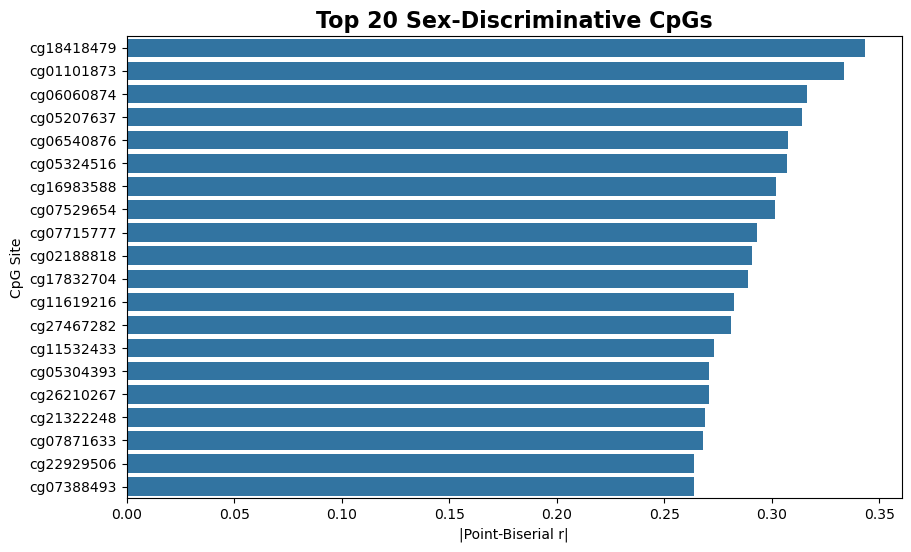

In [18]:
# |point-biserial r| corrs
pb_corrs = []
for col in X_train_sex.columns:
    corr, _ = pointbiserialr(np.ravel(y_train_sex), X_train_sex[col])
    pb_corrs.append((col, abs(corr)))

pb_corrs.sort(key=lambda x: x[1], reverse=True)
top20_sex_cpgs = pb_corrs[:20]

# Barplot Top 20
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in top20_sex_cpgs], y=[x[0] for x in top20_sex_cpgs])
plt.title("Top 20 Sex-Discriminative CpGs", fontsize=16, fontweight='bold')
plt.xlabel("|Point-Biserial r|")
plt.ylabel("CpG Site")

plt.savefig(f'{project_root}/figures/B_top20_sex.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# mRMR
mrmr_rank_sex = mrmr_regression(X=X_train_sex, y=y_train_sex, K=200, return_scores=False, show_progress=False)

LogRes = LogisticRegression(max_iter=1000)

ks = list(range(10, 201, 5))
accuracies = []

for k in ks:
    feats = mrmr_rank_sex[:k]
    LogRes.fit(X_train_sex[feats], y_train_sex)
    
    y_hat_sex = LogRes.predict(X_val_sex[feats])
    
    accuracies.append(accuracy_score(y_val_sex, y_hat_sex))

In [30]:
optimal_k_sex = ks[np.argmin(accuracies)]
mrmr_sex_feats = mrmr_rank_sex[:optimal_k_sex]

print(f"Optimal K: {optimal_k_sex}")

Optimal K: 10


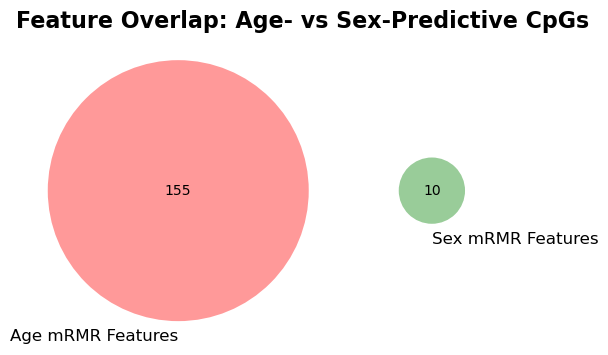

In [31]:
# venn overlap (Age vs Sex)

with open(f'{project_root}/data/mrmr_feats_age.json', "r") as f:
    mrmr_feats_age = json.load(f)

plt.figure(figsize=(6,6))
venn2([set(mrmr_feats_age), set(mrmr_sex_feats)], 
      set_labels=('Age mRMR Features', 'Sex mRMR Features'))
plt.title("Feature Overlap: Age- vs Sex-Predictive CpGs", fontsize=16, fontweight='bold', x=0.6, y=1.0)
plt.savefig(f'{project_root}/figures/B_venn.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
X_dev_sex = pd.concat([X_train_sex[mrmr_sex_feats], X_val_sex[mrmr_sex_feats]], axis=0)
y_dev_sex = np.ravel(pd.concat([y_train_sex, y_val_sex], axis=0))

X_test_sex = X_test_sex[mrmr_sex_feats]
y_test_sex = np.ravel(y_test_sex)

In [37]:
LogRes = LogisticRegression(max_iter=1000)
LogRes.fit(X_dev_sex, y_dev_sex)

GNB = GaussianNB()
GNB.fit(X_dev_sex, y_dev_sex)

LogRes_results, LogRes_metrics = bootstrap_classification(LogRes, X_test_sex, y_test_sex)
GNB_results, GNB_metrics = bootstrap_classification(GNB, X_test_sex, y_test_sex)

In [38]:
pd.DataFrame([LogRes_results], index=['LogReg'])

,Accuracy,F1,MCC,ROC-AUC,PR-AUC
LogReg,"0.800 ± 0.039, [0.720-0.870]","0.766 ± 0.051, [0.658-0.857]","0.593 ± 0.079, [0.428-0.741]","0.881 ± 0.033, [0.812-0.941]","0.867 ± 0.042, [0.769-0.938]"


In [39]:
pd.DataFrame([GNB_results], index=['GNB'])

,Accuracy,F1,MCC,ROC-AUC,PR-AUC
GNB,"0.730 ± 0.044, [0.640-0.810]","0.680 ± 0.059, [0.562-0.782]","0.448 ± 0.091, [0.263-0.617]","0.786 ± 0.047, [0.690-0.873]","0.737 ± 0.071, [0.583-0.858]"


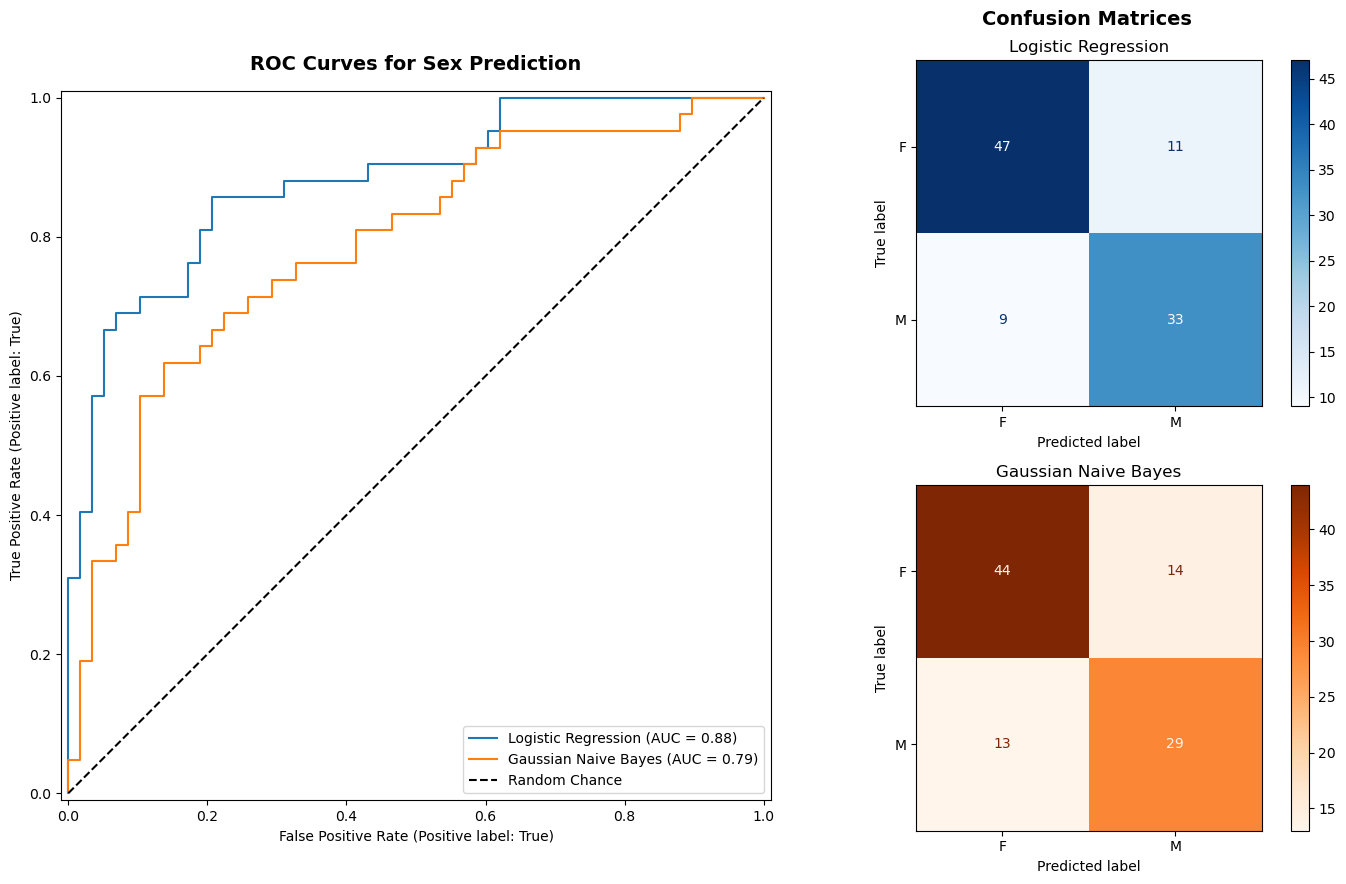

In [40]:
# ROC & ConfMatrices
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1]) 

ax_roc = fig.add_subplot(gs[:, 0])
ax_cm_lr = fig.add_subplot(gs[0, 1])
ax_cm_gnb = fig.add_subplot(gs[1, 1])

# ROC (Left)
RocCurveDisplay.from_estimator(LogRes, X_test_sex, y_test_sex, ax=ax_roc, name='Logistic Regression')
RocCurveDisplay.from_estimator(GNB, X_test_sex, y_test_sex, ax=ax_roc, name='Gaussian Naive Bayes')
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='k', label='Random Chance')
ax_roc.set_title("ROC Curves for Sex Prediction", fontsize=14, fontweight='bold', pad=15)
ax_roc.legend(loc='lower right')

# Confusion Matrices (Right)
ConfusionMatrixDisplay.from_estimator(LogRes, X_test_sex, y_test_sex, ax=ax_cm_lr, cmap='Blues', display_labels=['F', 'M'])
ax_cm_lr.set_title('Logistic Regression', fontsize=12)

ConfusionMatrixDisplay.from_estimator(GNB, X_test_sex, y_test_sex, ax=ax_cm_gnb, cmap='Oranges', display_labels=['F', 'M'])
ax_cm_gnb.set_title('Gaussian Naive Bayes', fontsize=12)

fig.text(0.78, 0.96, 'Confusion Matrices', fontsize=14, fontweight='bold', ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{project_root}/figures/B_ROC_conf.png', dpi=300, bbox_inches='tight')
plt.show()

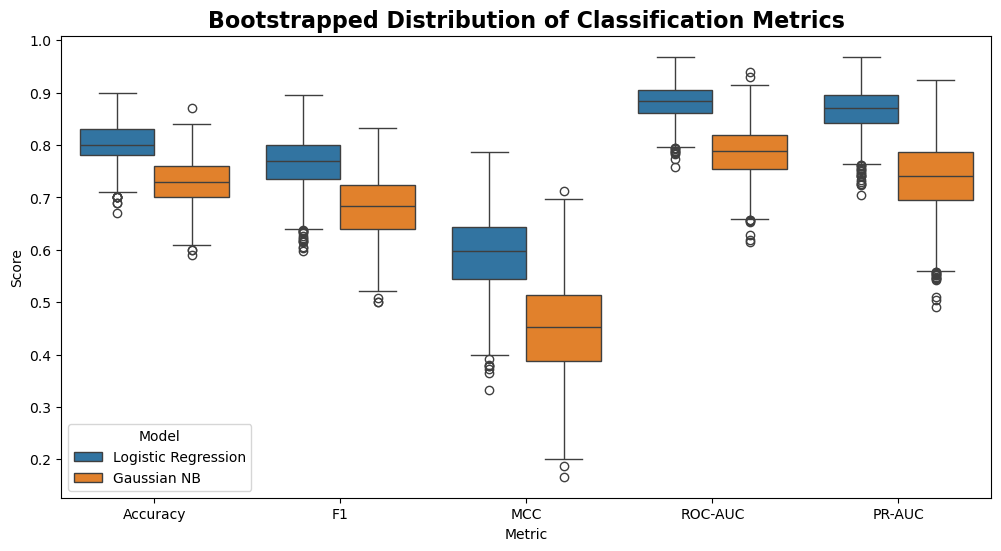

In [41]:
# boxplots

lr_df = pd.DataFrame(LogRes_metrics)
lr_df['Model'] = 'Logistic Regression'

gnb_df = pd.DataFrame(GNB_metrics)
gnb_df['Model'] = 'Gaussian NB'

plot_df = pd.concat([lr_df, gnb_df]).melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x='Metric', y='Score', hue='Model')
plt.title("Bootstrapped Distribution of Classification Metrics", fontsize=16, fontweight='bold')
plt.savefig(f'{project_root}/figures/B_boxplots.png', dpi=300, bbox_inches='tight')

plt.show()